In [1]:
'''Problem statement: A stock price always fluctuates,  but is there a relation
    between a closing price and its moving average.
    
    I want to showcase how the stock would move, I have five years of stock 
    price data with me in which I need to perform the analysis.
    
Objective: Find the futuristic movement of the stock 'GOOG' based on the
        price for the last five years

Perform the following steps:
    1. Get five years from finance package with tickler symbol 'GOOG'.
    2. Create 50DMA and 200DMA
    3. Plot it with the actual price
    4. Basic EDA on the data
    5. Fit statsmodel OLS to find the best possible features'''

"Problem statement: A stock price always fluctuates,  but is there a relation\n    between a closing price and its moving average.\n    \n    An analyst wants to showcase how the stock would move, he has five years\n    of stock price data with him on which he needs to perform the analysis.\n    \nObjective: Find the futuristic movement of the stock 'GOOG' based on the\n        price for the last five years\n\nPerform the following steps:\n    1. Get five years from finance package with tickler symbol 'GOOG'.\n    2. Create 50DMA and 200DMA\n    3. Plot it with the actual price\n    4. Basic EDA on the data\n    5. Fit statsmodel OLS to find the best possible features"

In [2]:
import yfinance as yahooFinance
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

C:\Users\dayoo\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\dayoo\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
google = yahooFinance.Ticker('GOOGL')

In [4]:
# % years of data
df = google.history(period='5y')


'import yfinance as yf\n\nticker = yf.Ticker("AAPL")\ndf = ticker.history(period="5y")\nprint(df.head())\n'

In [5]:
# Print the head of the data
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2020-04-13 00:00:00-04:00,59.789153,60.437056,58.835214,60.232533,38702000,0.0,0.0
2020-04-14 00:00:00-04:00,61.703500,63.483986,61.134717,62.960491,63358000,0.0,0.0
2020-04-15 00:00:00-04:00,62.028942,63.452138,61.406418,62.565876,42236000,0.0,0.0
2020-04-16 00:00:00-04:00,63.055532,63.365053,61.615419,62.572342,57896000,0.0,0.0
2020-04-17 00:00:00-04:00,63.780066,64.193092,62.998801,63.645710,51050000,0.0,0.0


In [6]:
# Print the tail of the data
df.tail()


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-04-07 00:00:00-04:00,141.550003,152.850006,140.529999,146.750000,76794100,0.0,0.0
2025-04-08 00:00:00-04:00,151.220001,152.240005,143.029999,144.699997,52200200,0.0,0.0
2025-04-09 00:00:00-04:00,144.419998,159.550003,143.910004,158.710007,70406200,0.0,0.0
2025-04-10 00:00:00-04:00,156.539993,157.720001,149.929993,152.820007,48022000,0.0,0.0
2025-04-11 00:00:00-04:00,152.899994,157.669998,152.820007,157.139999,33595900,0.0,0.0


In [7]:
df.shape  # I want to understand the shape of the dataset

(1258, 7)

In [8]:
df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03,1258.000000,1258.000000
mean,124.568426,126.016526,123.223189,124.636234,3.217679e+07,0.000636,0.015898
std,32.636024,32.888749,32.347432,32.607889,1.344129e+07,0.011264,0.563884
min,59.789153,60.437056,58.835214,60.232533,9.312000e+06,0.000000,0.000000
25%,99.561510,101.288247,98.596112,99.994558,2.335925e+07,0.000000,0.000000
50%,124.986194,126.032443,123.341308,124.742359,2.901835e+07,0.000000,0.000000
75%,144.381965,145.817855,143.164777,144.730381,3.700310e+07,0.000000,0.000000
max,203.156027,206.811821,202.576693,206.142593,1.232000e+08,0.200000,20.000000


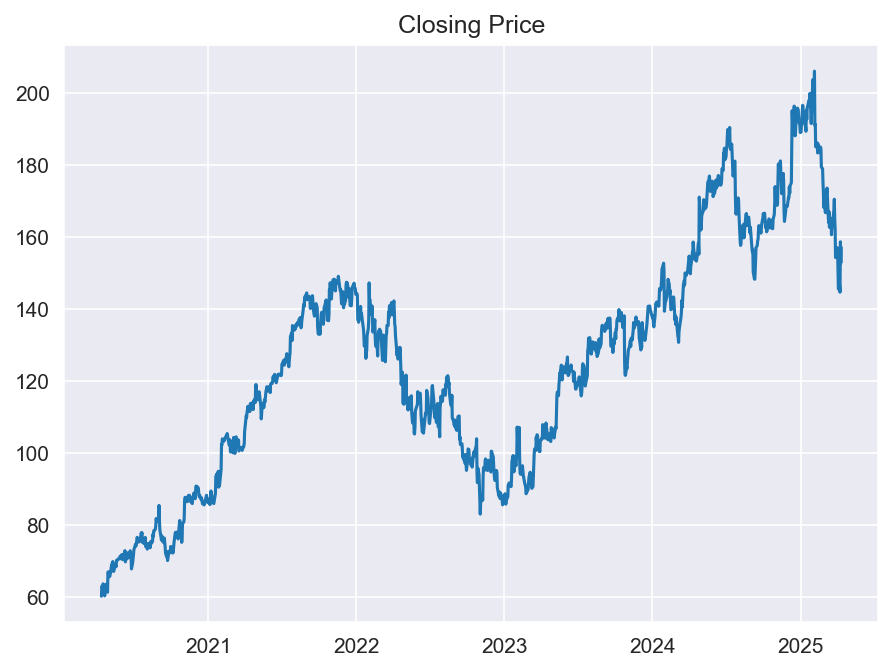

In [9]:
# General Overview of the closing price before calculating DNAs
sns.set_style('darkgrid')
plt.figure(figsize = (7,5), dpi = 150)
plt.title('Closing Price')
plt.plot(df['Close'])

In [10]:
# Calculating 50DMA
df['fiftyDMA'] = df['Close'].rolling(50).mean()

In [11]:
# Calculate 200DMA
df['twohundredDMA'] = df['Close'].rolling(200).mean()

In [12]:
df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,fiftyDMA,twohundredDMA
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03,1258.000000,1258.000000,1209.000000,1059.000000
mean,124.568426,126.016526,123.223189,124.636234,3.217679e+07,0.000636,0.015898,125.048573,124.809758
std,32.636024,32.888749,32.347432,32.607889,1.344129e+07,0.011264,0.563884,31.079311,24.293443
min,59.789153,60.437056,58.835214,60.232533,9.312000e+06,0.000000,0.000000,68.022984,77.323224
25%,99.561510,101.288247,98.596112,99.994558,2.335925e+07,0.000000,0.000000,98.862543,104.699331
50%,124.986194,126.032443,123.341308,124.742359,2.901835e+07,0.000000,0.000000,125.303609,124.318440
75%,144.381965,145.817855,143.164777,144.730381,3.700310e+07,0.000000,0.000000,142.067982,137.316373
max,203.156027,206.811821,202.576693,206.142593,1.232000e+08,0.200000,20.000000,191.864431,175.343954


In [13]:
# It Looks like Dividends and Stock Splits (null) columns and replace it with
# fiftyDMA and twohundredDMA

df.drop(columns = ['Dividends','Stock Splits'], inplace = True)   

df.head()

,Open,High,Low,Close,Volume,fiftyDMA,twohundredDMA
Date,,,,,,,
2020-04-13 00:00:00-04:00,59.789153,60.437056,58.835214,60.232533,38702000,NaN,NaN
2020-04-14 00:00:00-04:00,61.703500,63.483986,61.134717,62.960491,63358000,NaN,NaN
2020-04-15 00:00:00-04:00,62.028942,63.452138,61.406418,62.565876,42236000,NaN,NaN
2020-04-16 00:00:00-04:00,63.055532,63.365053,61.615419,62.572342,57896000,NaN,NaN
2020-04-17 00:00:00-04:00,63.780066,64.193092,62.998801,63.645710,51050000,NaN,NaN


In [14]:
df.tail()

,Open,High,Low,Close,Volume,fiftyDMA,twohundredDMA
Date,,,,,,,
2025-04-07 00:00:00-04:00,141.550003,152.850006,140.529999,146.750000,76794100,174.262187,173.854442
2025-04-08 00:00:00-04:00,151.220001,152.240005,143.029999,144.699997,52200200,173.324400,173.699630
2025-04-09 00:00:00-04:00,144.419998,159.550003,143.910004,158.710007,70406200,172.597094,173.598277
2025-04-10 00:00:00-04:00,156.539993,157.720001,149.929993,152.820007,48022000,171.749790,173.469518
2025-04-11 00:00:00-04:00,152.899994,157.669998,152.820007,157.139999,33595900,170.879811,173.338395


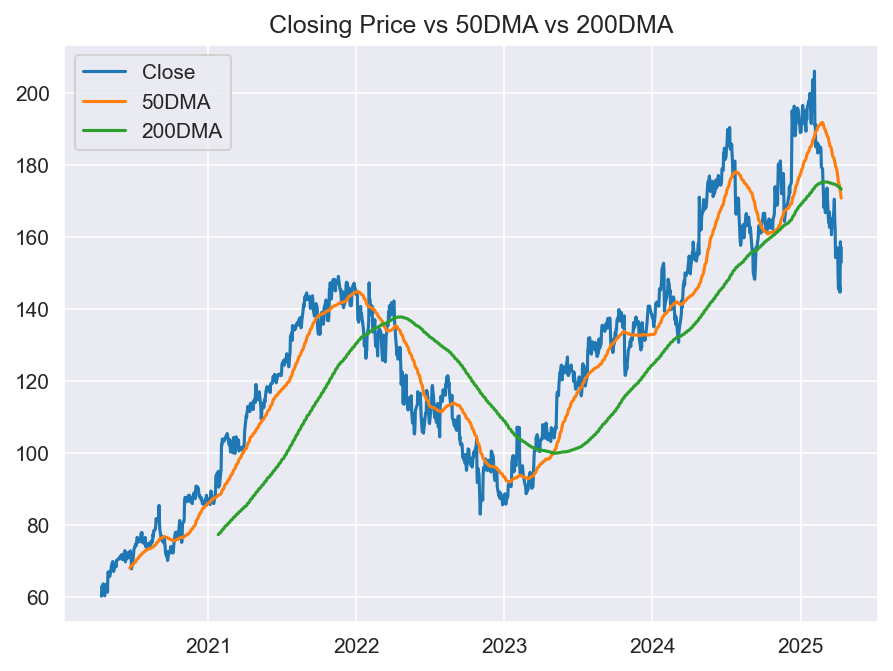

In [15]:
# Plotting closing price vs 50DMA vs 200DMA

sns.set_style('darkgrid')
plt.figure(figsize = (7,5), dpi = 150)
plt.title('Closing Price vs 50DMA vs 200DMA')
plt.plot(df['Close'], label = 'Close')
plt.plot(df['fiftyDMA'], label = '50DMA')
plt.plot(df['twohundredDMA'], label = '200DMA')
plt.legend()

In [16]:
'''Inference on the graph:
    
The 50-day and 200-day moving averages (50DMA and 200DMA) are pretty reliable 
indicators of a stock’s movement. Typically:

1. If the closing price is above both the 50DMA and 200DMA, the stock is 
   trending upward or showing bullish behavior.
2. On the other hand, if the closing price is below these averages, it’s 
   usually heading downward.
3. Whenever the 50DMA and 200DMA intersect, it often signals a market trend 
   reversal—like a shift from highs to lows or vice versa.
4. One notable example is the steep drop in March 2020, which reflects the 
   market crash caused by COVID-19.
'''

'Inference on the graph:\n    \nThe 50-day and 200-day moving averages (50DMA and 200DMA) are pretty reliable \nindicators of a stock’s movement. Typically:\n\n1. If the closing price is above both the 50DMA and 200DMA, the stock is \n   trending upward or showing bullish behavior.\n2. On the other hand, if the closing price is below these averages, it’s \n   usually heading downward.\n3. Whenever the 50DMA and 200DMA intersect, it often signals a market trend \n   reversal—like a shift from highs to lows or vice versa.\n4. One notable example is the steep drop in March 2020, which reflects the \n   market crash caused by COVID-19.\n'

In [17]:
# Finding the possible futuristic movement of the stock

# Analyse correlation between each variables

<AxesSubplot:>

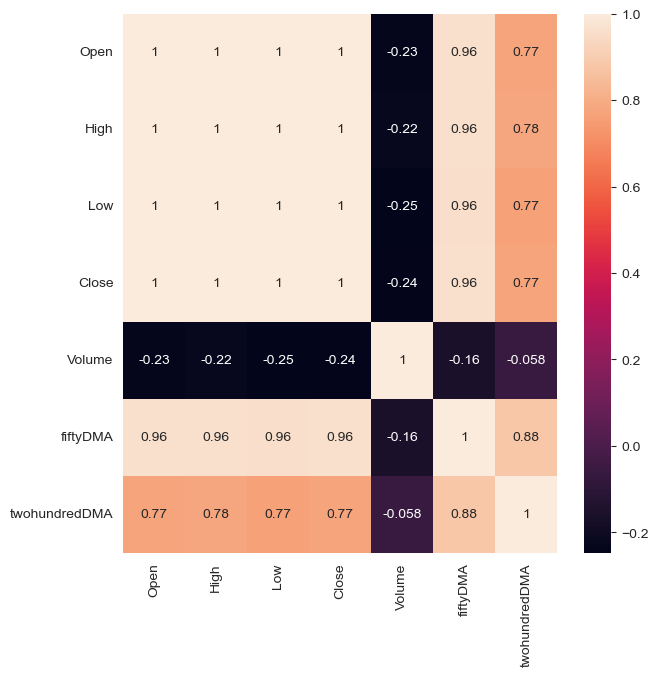

In [18]:
plt.figure(figsize = (7,7), dpi = 100)
sns.heatmap(df.corr(), annot = True)

In [19]:
'''Looking at the heatmap, we can infer a few key points:
1. The "Close" value shows a strong correlation with nearly all the other 
   variables, except for "Volume," where the relationship is weak.
2. There’s noticeable multicollinearity among the variables, indicating that 
   they’re highly interrelated.
'''

'Looking at the heatmap, we can infer a few key points:\n1. The "Close" value shows a strong correlation with nearly all the other \n   variables, except for "Volume," where the relationship is weak.\n2. There’s noticeable multicollinearity among the variables, indicating that \n   they’re highly interrelated.\n'

<AxesSubplot:title={'center':'Distplot 50DMA '}, xlabel='fiftyDMA', ylabel='Density'>

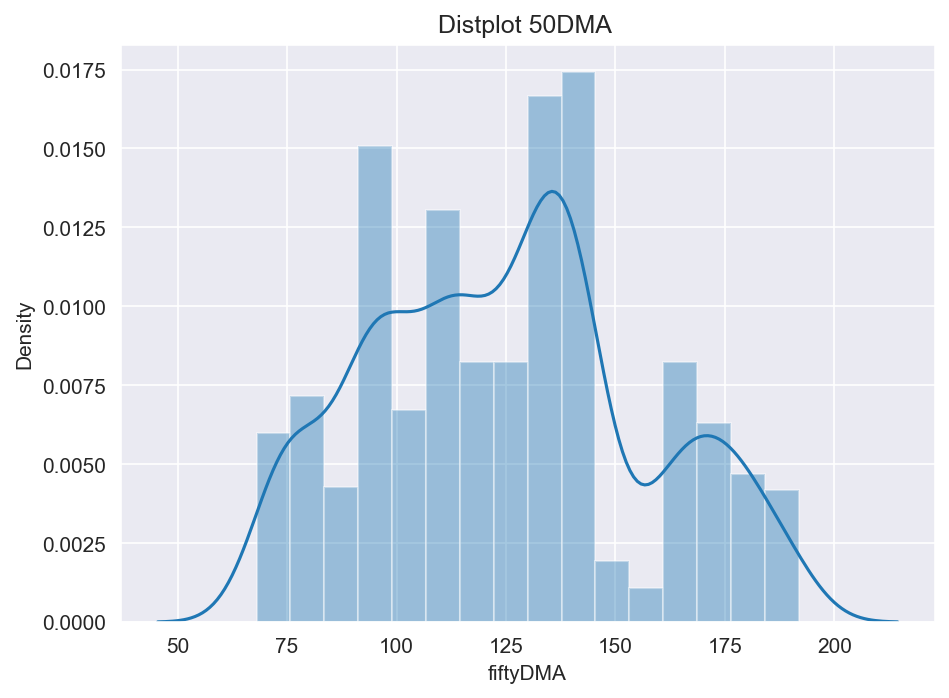

In [20]:
# Plotting distplot for 50DMA since 50DMA and 200DMA are closely correlated 
# so use only 50DMA
 

sns.set_style('darkgrid')
plt.figure(figsize = (7,5), dpi = 150)
plt.title('Distplot 50DMA ')
sns.distplot(df['fiftyDMA'])

<AxesSubplot:title={'center':'Distplot of closing price '}, xlabel='Close', ylabel='Density'>

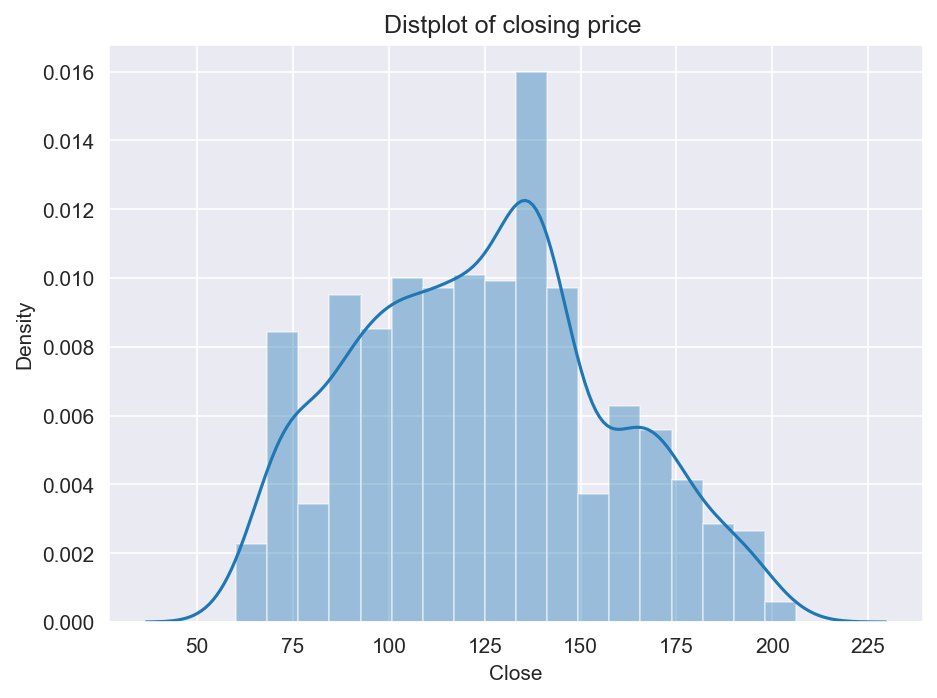

In [21]:
# Plot distplot for Closing price

sns.set_style('darkgrid')
plt.figure(figsize = (7,5), dpi = 150)
plt.title('Distplot of closing price ')
sns.distplot(df['Close'])

In [22]:
# Now let us press further by doing a little more statistics

In [31]:
# We need to avoid multi colinearity so we have to fit the data


In [30]:
import statsmodels.formula.api as smf
model = smf.ols(formula='Close ~ fiftyDMA', data=df)
fitted_model = model.fit()
print(fitted_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Close   R-squared:                       0.925
Model:                            OLS   Adj. R-squared:                  0.925
Method:                 Least Squares   F-statistic:                 1.491e+04
Date:                Mon, 14 Apr 2025   Prob (F-statistic):               0.00
Time:                        12:29:44   Log-Likelihood:                -4305.9
No. Observations:                1209   AIC:                             8616.
Df Residuals:                    1207   BIC:                             8626.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.3949      1.017      6.286      0.0

In [25]:
'''From the summary, we can draw a couple of key conclusions:

1. The model shows strong r-squared values and coefficients, indicating a 
   good fit overall.
2. However, due to the extremely high correlation between variables, it 
   wouldn’t be practical to rely on this parameter for r '''



'From the summary, we can draw a couple of key conclusions:\n\n1. The model shows strong r-squared values and coefficients, indicating a \n   good fit overall.\n2. However, due to the extremely high correlation between variables, it \n   wouldn’t be practical to rely on this parameter for r '

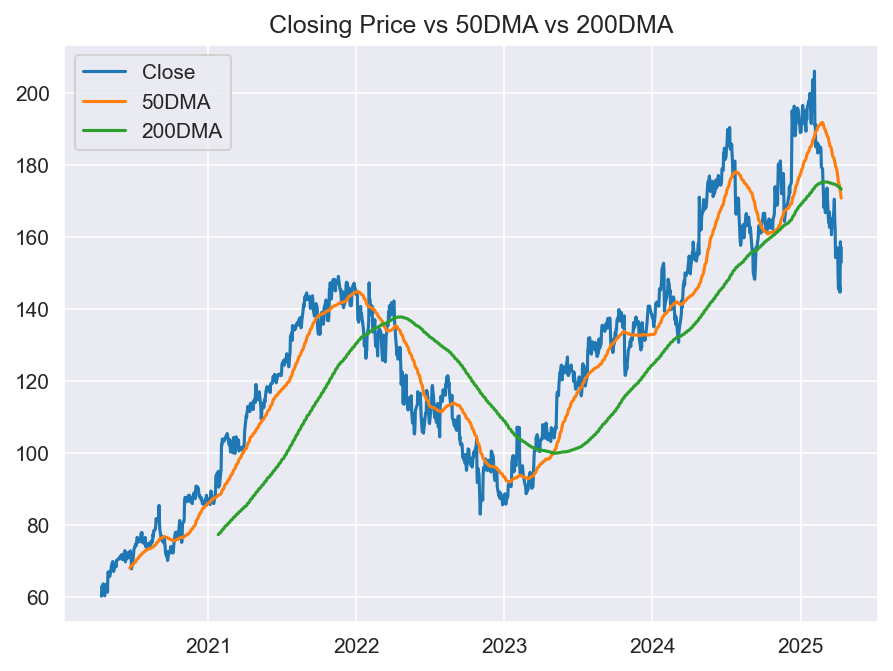

In [26]:
sns.set_style('darkgrid')
plt.figure(figsize = (7,5), dpi = 150)
plt.title('Closing Price vs 50DMA vs 200DMA')
plt.plot(df['Close'], label = 'Close')
plt.plot(df['fiftyDMA'], label = '50DMA')
plt.plot(df['twohundredDMA'], label = '200DMA')
plt.legend()